<a href="https://colab.research.google.com/github/Claud1601/CN7030-Assignment/blob/main/Protfolio_Exercise_lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the Titanic dataset
titanic_df = pd.read_csv('/content/titanic_synthetic_data.csv')

# Display the first 5 rows of the dataset
print("First 5 rows of the Titanic dataset:")
display(titanic_df.head())

First 5 rows of the Titanic dataset:


,Pclass,Age,SibSp,Parch,Fare,Sex,Survived,Embarked_Q,Embarked_S
0,3,42,6,7,397.001784,0.0,0.0,0.0,1.0
1,1,52,6,7,302.127700,0.0,0.0,1.0,0.0
2,3,25,3,8,427.105877,1.0,1.0,1.0,0.0
3,3,32,9,7,326.804992,1.0,0.0,0.0,0.0
4,1,40,0,5,17.718838,0.0,0.0,0.0,0.0


In [ ]:
# Display basic information about the dataset
print("\nDataset Information:")
titanic_df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326598 entries, 0 to 326597
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Pclass      326598 non-null  int64  
 1   Age         326598 non-null  int64  
 2   SibSp       326598 non-null  int64  
 3   Parch       326598 non-null  int64  
 4   Fare        326598 non-null  float64
 5   Sex         326597 non-null  float64
 6   Survived    326597 non-null  float64
 7   Embarked_Q  326597 non-null  float64
 8   Embarked_S  326597 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 22.4 MB



Distribution of 'Survived' column:


,count
Survived,
0.0,163354
1.0,163243


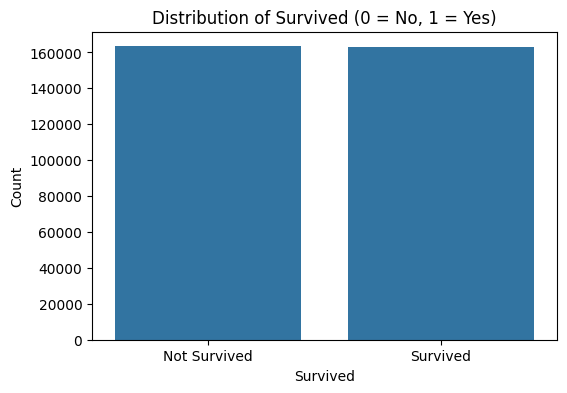

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for class imbalance in the 'Survived' column
print("\nDistribution of 'Survived' column:")
survived_counts = titanic_df['Survived'].value_counts()
display(survived_counts)

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=survived_counts.index, y=survived_counts.values)
plt.title('Distribution of Survived (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Survived', 'Survived'])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y)
# Drop 'Sex' as it's already encoded, if not, it should be one-hot encoded
# Drop 'Embarked_Q' and 'Embarked_S' as they are already encoded.
# Assuming Pclass, Age, SibSp, Parch, Fare, Sex, Embarked_Q, Embarked_S are the features.
# The original dataset likely had a 'Sex' and 'Embarked' column that were then encoded.
# Given the current column names, we'll use all numerical columns as features except 'Survived'.

X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (261278, 8)
Shape of X_test: (65320, 8)
Shape of y_train: (261278,)
Shape of y_test: (65320,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# --- Start of the fix: Handle missing values ---
# Drop rows where X_train or y_train contains NaN values
# This ensures that both features and target are clean for training
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined_cleaned = train_combined.dropna()
X_train = train_combined_cleaned.drop(columns=['Survived'])
y_train = train_combined_cleaned['Survived']

# Drop rows where X_test or y_test contains NaN values
# This ensures that both features and target are clean for evaluation
test_combined = pd.concat([X_test, y_test], axis=1)
test_combined_cleaned = test_combined.dropna()
X_test = test_combined_cleaned.drop(columns=['Survived'])
y_test = test_combined_cleaned['Survived']
# --- End of the fix ---

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model Evaluation:
Accuracy: 0.4999

Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.54      0.52     32646
         1.0       0.50      0.46      0.48     32674

    accuracy                           0.50     65320
   macro avg       0.50      0.50      0.50     65320
weighted avg       0.50      0.50      0.50     65320


Confusion Matrix:
[[17752 14894]
 [17771 14903]]


In [ ]:
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

# The 'Embarked' column has likely been one-hot encoded into 'Embarked_Q' and 'Embarked_S'.
# Thus, the original 'Embarked' column no longer exists, and this step is not needed.
# If there were NaNs in 'Embarked_Q' or 'Embarked_S', they should be handled as part of those columns.
# titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)

# Drop Cabin because too many missing values
if 'Cabin' in titanic_df.columns:
    titanic_df.drop('Cabin', axis=1, inplace=True)

# Drop unnecessary columns
drop_cols = ['PassengerId', 'Name', 'Ticket']
for col in drop_cols:
    if col in titanic_df.columns:
        titanic_df.drop(col, axis=1, inplace=True)

/tmp/ipykernel_9212/2341778407.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)


In [ ]:
# Check for any remaining missing values after cleaning
print("\nMissing values after cleaning:")
print(titanic_df.isnull().sum())


Missing values after cleaning:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex           1
Survived      1
Embarked_Q    1
Embarked_S    1
dtype: int64


In [ ]:
# Drop any remaining rows with NaN values from the main DataFrame
titanic_df.dropna(inplace=True)

print("\nMissing values after final dropna:")
print(titanic_df.isnull().sum())


Missing values after final dropna:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex           0
Survived      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [ ]:
# The 'Sex' column appears to be already numerically encoded (0.0, 1.0).
# The 'Embarked' column has been one-hot encoded into 'Embarked_Q' and 'Embarked_S'.
# Thus, these encoding steps are not needed at this point and would cause errors.
# If you intended to encode 'Sex' or 'Embarked' from string categories, that should occur earlier in the data preprocessing pipeline.

In [ ]:
model = LogisticRegression(max_iter=1000)

# The variables X_train_smote and y_train_smote are not defined.
# Assuming the intent was to use the previously defined X_train and y_train.
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\nModel Evaluation (after cleaning and retraining):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model Evaluation (after cleaning and retraining):
Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.54      0.52     32646
         1.0       0.50      0.46      0.48     32674

    accuracy                           0.50     65320
   macro avg       0.50      0.50      0.50     65320
weighted avg       0.50      0.50      0.50     65320


Confusion Matrix:
[[17682 14964]
 [17693 14981]]
